# 52.3 · Async pipelines and profiling

CPU · Python 3.11–3.13 · seeded teaching experiment

[Open in Google Colab](https://colab.research.google.com/) — use the [ZIP setup workflow](../../docs/colab.md). No model or dataset downloads occur in this notebook.

## Learning Objectives

- Explain async pipelines and profiling using the chapter's assumptions.
- Translate the worked equation into Python and inspect an implementation.
- Run, visualize and critique a reproducible experiment.

## Prerequisites

[15 · Video Processing](../../15-video-processing/README.md), [36 · Multi-Object Tracking](../../36-multi-object-tracking/README.md), [49 · Model Optimization](../../49-model-optimization/README.md), [50 · Computer Vision Deployment](../../50-computer-vision-deployment/README.md)

Install the repository before opening this notebook: `python -m pip install -e ".[notebooks,deep,api]"`. The deep/API extras are needed only by chapters that use them.

## 1. Introduction

Real-time vision is about meeting timing needs on current frames. Throughput measures completed work per second; latency measures delay; frame age measures how stale a result is. A fast model can still produce unusable output if queues grow without bounds.

## 2. Intuition

Threads can overlap I/O and native-library work; Python-heavy CPU loops may need vectorization or processes. Async code helps coordinate waiting but does not make CPU inference free. The dashboard permits one in-flight request to bound browser-side accumulation. Measure each stage before adding concurrency.

In [1]:
import inspect
import json
import platform
from importlib.metadata import version

import cv2
from IPython.display import Code, display

from cvzero.course.runner import lab_function, run

CHAPTER = 52
LESSON = 2
SEED = 42
AMOUNT = 1.0
print(
    {
        "python": platform.python_version(),
        "numpy": version("numpy"),
        "opencv": cv2.__version__,
        "device": "cpu",
        "seed": SEED,
    }
)

{'python': '3.12.14', 'numpy': '2.3.5', 'opencv': '4.14.0', 'device': 'cpu', 'seed': 42}


## 3. Mathematical Foundation

$$
\rho=\lambda s
$$

λ is arrival rate in frames/second, s mean service seconds/frame and ρ utilization. At 30 FPS and 0.045 seconds of service, ρ=1.35, so one worker cannot keep up indefinitely without dropping or reducing input.

Read the symbols aloud, predict the numerical result, and only then execute the worked example.

## 4. Visual Explanation

The chapter preview shows an actual baseline run. Read every panel title before interpreting color or brightness; some panels show a mask, an error, or a matrix rather than a photograph.

![Measured chapter baseline](../assets/lab-preview.png)

## 5. Basic Implementation

This small calculation isolates the equation from the larger pipeline. Change one number and predict its effect before rerunning.

In [2]:
arrival_fps, service_seconds = 30.0, 0.045
utilization = arrival_fps * service_seconds
assert utilization > 1
print(utilization)

1.3499999999999999


## 6. OpenCV Implementation

The relevant library is selected by the problem: OpenCV for image operations and geometry, scikit-learn for classical learning, PyTorch for differentiable models, and FastAPI for service contracts. OpenCV handles image arrays where it is useful; it does not supply every advanced model.

The scheduling simulator advances event times, completes active work and drops the oldest waiting frame when capacity is exceeded. Its output is a simulated latency distribution, not a hardware FPS claim.

The lab function below calls the actual implementation. Inspect its source to see preprocessing, fixed hyperparameters and reported metrics.

In [3]:
display(Code(inspect.getsource(lab_function(CHAPTER)), language="python"))
result = run(CHAPTER, lesson=LESSON, seed=SEED, amount=AMOUNT)
print(json.dumps(result.metrics, indent=2))
print(result.notes)

def realtime(lesson=0, seed=42, amount=1.0):
    arrivals = np.arange(90) / 30
    duration = 0.045 * amount
    bounded, drops = queue_simulation(arrivals, duration, 2)
    fifo, _ = queue_simulation(arrivals, duration, 1000)
    return Result(
        "52 · Bounded queues and frame age",
        curves={"FIFO latency seconds": fifo, "Latest bounded queue latency seconds": bounded},
        metrics={
            "input_frames": len(arrivals),
            "bounded_processed": len(bounded),
            "bounded_dropped": drops,
            "bounded_p95_seconds": float(np.percentile(bounded, 95)),
            "fifo_p95_seconds": float(np.percentile(fifo, 95)),
        },
        notes="Deterministic scheduling simulation, not a measured FPS benchmark. Dropped frames change tracking time steps; production motion models must use timestamps, not assume a fixed unit interval.",
    )

{
  "input_frames": 90,
  "bounded_processed": 68,
  "bounded_dropped": 22,
  "bounded_p95_seconds": 0.10999999999999882,
  "fifo_p95_seconds": 1.0314166666666629
}
Deterministic scheduling simulation, not a measured FPS benchmark. Dropped frames change tracking time steps; production motion models must use timestamps, not assume a fixed unit interval.


## 7. From-Scratch Implementation

Read the following reusable reference implementation line by line. Identify input shapes, the main update or reduction, and the boundary/invalid-input policy. Its source lives in `src/cvzero/course/engineering.py`; notebooks reuse it so fixes apply everywhere. Optimized libraries are compared where matching behavior is meaningful.

In [4]:
from cvzero.course.engineering import queue_simulation

display(Code(inspect.getsource(queue_simulation), language="python"))

def queue_simulation(arrivals, service_seconds, capacity=2):
    """Discrete-event latest-frame queue. Returns completed latencies and drops."""
    if service_seconds <= 0 or capacity < 1:
        raise ValueError("Positive service time and capacity required.")
    waiting = []
    completed = []
    dropped = 0
    busy_until = None
    active = None
    for arrival in arrivals:
        while busy_until is not None and busy_until <= arrival:
            completed.append(busy_until - active)
            if waiting:
                active = waiting.pop(0)
                busy_until += service_seconds
            else:
                busy_until = None
                active = None
        if busy_until is None:
            active = float(arrival)
            busy_until = active + service_seconds
        else:
            if len(waiting) >= capacity:
                waiting.pop(0)
                dropped += 1
            waiting.append(float(arrival))
    while busy_until is not None:
        completed.append(busy_until - active)
        if waiting:
            active = waiting.pop(0)
            busy_until += service_seconds
        else:
            busy_until = None
    return np.array(completed), dropped

## 8. Experiment

Compare FIFO and bounded queues under a service-time spike. Report dropped frames alongside p50 and p95 frame latency.

The run configuration is defined above. `lesson` selects the chapter experiment, `seed` fixes generated data or initialization, and `amount` controls the active experiment's perturbation when supported. Consult the displayed function before changing it: a fixed mathematical example may deliberately ignore a random seed or perturbation. Keep all other settings fixed when testing one hypothesis.

In [5]:
# A second independent seed checks sensitivity; fixed examples may remain identical.
repeat = run(CHAPTER, lesson=LESSON, seed=SEED + 1, amount=AMOUNT)
print(json.dumps({"baseline": result.metrics, "second_seed": repeat.metrics}, indent=2))

{
  "baseline": {
    "input_frames": 90,
    "bounded_processed": 68,
    "bounded_dropped": 22,
    "bounded_p95_seconds": 0.10999999999999882,
    "fifo_p95_seconds": 1.0314166666666629
  },
  "second_seed": {
    "input_frames": 90,
    "bounded_processed": 68,
    "bounded_dropped": 22,
    "bounded_p95_seconds": 0.10999999999999882,
    "fifo_p95_seconds": 1.0314166666666629
  }
}


## 9. Visualization

These figures are generated by the current run. The second plot uses the second seed. Compare the numerical report with the visible result; a single scalar rarely explains every failure.

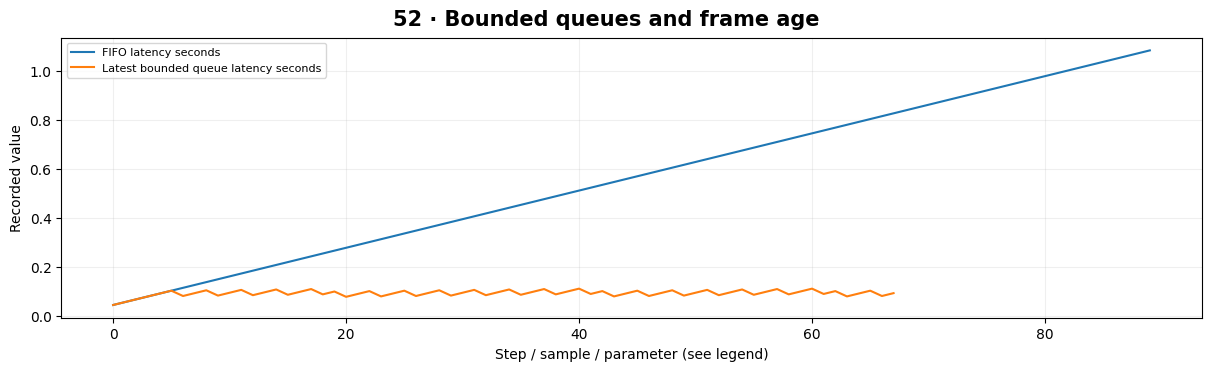

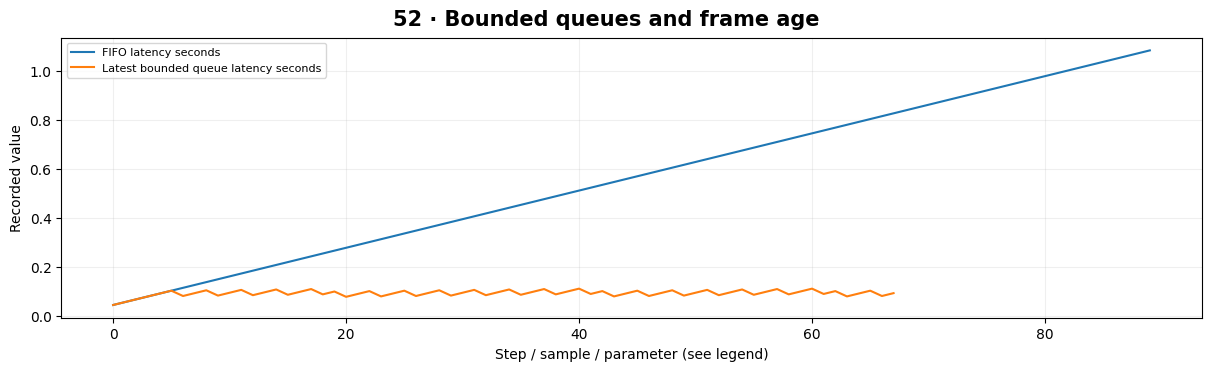

In [6]:
display(result.plot())
display(repeat.plot())

## 10. Real-World Application

The chapter mini project is **Real-Time Analytics Dashboard**. Keep displays responsive while processing bounded work queues. Start with the generated data so expected geometry or labels are known, then use a separately documented real dataset. Do not transfer synthetic metrics to a real deployment claim.

## 11. Common Mistakes

Reporting average FPS hides long stalls. Repeated wait calls and unbounded queues can make live results increasingly stale.

Check shape, dtype, units, split and coordinate conventions before tuning an algorithm.

## 12. Exercises

- **Easy:** Reproduce the worked numerical example by hand and add a second case.
- **Medium:** Compare FIFO and bounded queues under a service-time spike. Report dropped frames alongside p50 and p95 frame latency.
- **Hard:** Create a failure case for one assumption stated in this lesson and propose a measurable remedy.

## 13. Challenge

Build a bounded video pipeline with timestamps, backpressure, clean shutdown and a latency dashboard.

Write acceptance criteria before coding. No challenge solution is included beside the question.

## 14. Summary

Threads can overlap I/O and native-library work; Python-heavy CPU loops may need vectorization or processes. Async code helps coordinate waiting but does not make CPU inference free. The dashboard permits one in-flight request to bound browser-side accumulation. Measure each stage before adding concurrency.

**Checkpoint:** explain the mechanism, implement a small case, modify one parameter, debug a failure and apply it to a new example. Record evidence for all five.

## 15. Next Step

[53 · Production Computer Vision](../../53-production-computer-vision/README.md)

[Primary reference](https://docs.python.org/3/library/queue.html) · [Chapter exercises](../exercises/beginner.md) · [Mini project](../mini-project/README.md)